In [1]:
# Data Exploration Notebook
# This notebook explores the structure and content of the three datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set plotting style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# Display all columns
pd.set_option('display.max_columns', None)

print("NYC Data Analysis - Data Exploration")
print("=" * 50)

NYC Data Analysis - Data Exploration


In [5]:
# 1. Crime Data Exploration
print("\n1. Crime Data Exploration\n" + "-" * 30)

# Load the Excel file
crime_data = pd.read_excel('../data/311_Crime_NYPD.xlsx', sheet_name='311_Service_Requests_from_2010_')

# Display basic information
print(f"Crime data shape: {crime_data.shape}")
print("\nFirst few rows:")
print(crime_data.head())

# Check column types
print("\nCrime data column types:")
print(crime_data.dtypes)

# Check for missing values
print("\nMissing values in crime data:")
print(crime_data.isnull().sum())

# Check for unique values in key columns
print("\nUnique years in crime data:")
if 'Year' in crime_data.columns:
    print(crime_data['Year'].unique())
else:
    # Look for year column with different casing
    year_col = [col for col in crime_data.columns if col.lower() == 'year']
    if year_col:
        print(crime_data[year_col[0]].unique())
    else:
        print("Year column not found")

print("\nUnique ZIP codes in crime data:")
zip_col = [col for col in crime_data.columns if 'zip' in col.lower()]
if zip_col:
    print(crime_data[zip_col[0]].unique()[:20])  # Show first 20
    print(f"Total unique ZIP codes: {crime_data[zip_col[0]].nunique()}")
else:
    print("ZIP code column not found")


1. Crime Data Exploration
------------------------------
Crime data shape: (92765, 5)

First few rows:
   Unique Key by_year_created_date  Incident Zip  \
0          10           2011-01-01       10014.0   
1          57           2011-01-01       11231.0   
2          26           2011-01-01       11358.0   
3         305           2011-01-01       11233.0   
4          35           2011-01-01       10011.0   

                      Descriptor  Year  
0                     Unlicensed  2011  
1  Posted Parking Sign Violation  2011  
2                   Loud Talking  2011  
3                      No Access  2011  
4                Blocked Hydrant  2011  

Crime data column types:
Unique Key                       int64
by_year_created_date    datetime64[ns]
Incident Zip                   float64
Descriptor                      object
Year                             int64
dtype: object

Missing values in crime data:
Unique Key                 0
by_year_created_date       0
Incident Zip 

In [6]:
# 2. ACS Demographics Data Exploration
print("\n\n2. ACS Demographics Data Exploration\n" + "-" * 40)

# Load the CSV file
acs_data = pd.read_csv('../data/ACS_update.csv')

# Display basic information
print(f"ACS data shape: {acs_data.shape}")
print("\nFirst few rows:")
print(acs_data.head())

# Check column types
print("\nACS data column types:")
print(acs_data.dtypes)

# Check for missing values
print("\nMissing values in ACS data:")
print(acs_data.isnull().sum().sum())
print(f"Percentage of missing values: {acs_data.isnull().sum().sum() / (acs_data.shape[0] * acs_data.shape[1]) * 100:.2f}%")

# Check for unique values in key columns
print("\nUnique years in ACS data:")
print(acs_data['year'].unique())

print("\nUnique ZCTAs in ACS data:")
print(f"Number of unique ZCTAs: {acs_data['zcta'].nunique()}")
print(f"Sample ZCTAs: {acs_data['zcta'].unique()[:10]}")

# Summary statistics for key demographic variables
print("\nSummary statistics for key demographic variables:")
print(acs_data[['household_median_income_1yr', 'median_rent', 'total_population']].describe())



2. ACS Demographics Data Exploration
----------------------------------------
ACS data shape: (2348, 28)

First few rows:
    zcta  year   merge_key  number_of_households  household_median_income_1yr  \
0  10001  2023  2023_10001                 15097                       123393   
1  10002  2023  2023_10002                 35771                        46525   
2  10003  2023  2023_10003                 25080                       153750   
3  10004  2023  2023_10004                  1775                       220592   
4  10005  2023  2023_10005                  5156                       211810   

   household_mean_income_1yr  number_of_rent_home  median_rent  \
0                     205444                11399         3024   
1                      93314                28916         1207   
2                     248577                16196         2772   
3                     309645                 1145         3501   
4                     279387                 4276         3

In [7]:
# 3. Business and Gentrification Data Exploration
print("\n\n3. Business and Gentrification Data Exploration\n" + "-" * 50)

# Load the CSV file
business_data = pd.read_csv('../data/business_type_gentrification.csv')

# Display basic information
print(f"Business data shape: {business_data.shape}")
print("\nFirst few rows (selected columns):")
# Show just a subset of columns since there are many
selected_cols = [col for col in business_data.columns if col in ['', 'yr', 'is_gentrified', 'rent', 'rent_change', 'EXPENSIVE', 'INEXPENSIVE', 'MODERATE']]
print(business_data[selected_cols].head())

# Check column types
print("\nBusiness data column types (first 10):")
print(business_data.dtypes.head(10))

# Check for missing values
print("\nMissing values in business data:")
missing_count = business_data.isnull().sum().sum()
print(f"Total missing values: {missing_count}")
print(f"Percentage of missing values: {missing_count / (business_data.shape[0] * business_data.shape[1]) * 100:.2f}%")

# Check for unique values in key columns
print("\nUnique years in business data:")
print(business_data['yr'].unique())

print("\nZIP codes in business data:")
# Assuming the first unnamed column is the ZIP code
zip_col = business_data.columns[0]
print(f"Number of unique ZIP codes: {business_data[zip_col].nunique()}")
print(f"Sample ZIP codes: {business_data[zip_col].unique()[:10]}")

# Gentrification status
print("\nGentrification status counts:")
print(business_data['is_gentrified'].value_counts())



3. Business and Gentrification Data Exploration
--------------------------------------------------
Business data shape: (420, 134)

First few rows (selected columns):
   EXPENSIVE  INEXPENSIVE  MODERATE         rent  rent_change    yr  \
0       17.0         25.0      90.0  4870.677598     0.205286  2022   
1       12.0         62.0      75.0  3554.796326     0.244991  2022   
2       25.0         68.0     108.0  3941.807689     0.256503  2022   
3        2.0         13.0      11.0  3946.666521     0.044439  2022   
4        4.0          1.0       5.0  4275.182475     0.217989  2022   

   is_gentrified  
0          False  
1           True  
2           True  
3          False  
4          False  

Business data column types (first 10):
Unnamed: 0                   int64
ttl_acai_shop              float64
ttl_afghani_restaurant     float64
ttl_african_restaurant     float64
ttl_american_restaurant    float64
ttl_amusement_center       float64
ttl_art_gallery            float64
ttl_a

In [15]:
# 4. Data Integration Possibilities
print("\n\n4. Data Integration Possibilities\n" + "-" * 40)

# Check overlap in years
crime_years = set(crime_data['Year'].unique()) if 'Year' in crime_data.columns else set()
acs_years = set(acs_data['year'].unique())
business_years = set(business_data['yr'].unique())

print("Years available in each dataset:")
print(f"Crime data: {sorted(crime_years)}")
print(f"ACS data: {sorted(acs_years)}")
print(f"Business data: {sorted(business_years)}")

print("\nOverlap in years:")
print(f"Crime and ACS: {sorted(crime_years.intersection(acs_years))}")
print(f"Crime and Business: {sorted(crime_years.intersection(business_years))}")
print(f"ACS and Business: {sorted(acs_years.intersection(business_years))}")
print(f"All three datasets: {sorted(crime_years.intersection(acs_years).intersection(business_years))}")

# Check overlap in ZIP codes

crime_zips = set(crime_data['Incident Zip'].dropna().unique())

acs_zips = set(acs_data['zcta'].unique())
business_zips = set(business_data[business_data.columns[0]].unique())

print("\nNumber of ZIP codes in each dataset:")
print(f"Crime data: {len(crime_zips)}")
print(f"ACS data: {len(acs_zips)}")
print(f"Business data: {len(business_zips)}")

print("\nOverlap in ZIP codes:")
print(f"Crime and ACS: {len(crime_zips.intersection(acs_zips))}")
print(f"Crime and Business: {len(crime_zips.intersection(business_zips))}")
print(f"ACS and Business: {len(acs_zips.intersection(business_zips))}")
print(f"All three datasets: {len(crime_zips.intersection(acs_zips).intersection(business_zips))}")



4. Data Integration Possibilities
----------------------------------------
Years available in each dataset:
Crime data: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
ACS data: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Business data: [np.int64(2022), np.int64(2023), np.int64(2024)]

Overlap in years:
Crime and ACS: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Crime and Business: [np.int64(2022), np.int64(2023), np.int64(2024)]
ACS and Business: [np.int64(2022), np.int64(2023)]
All three datasets: [np.int64(2022), np.int64(2023)]

Number of ZIP cod

In [16]:
# 5. Initial Findings
print("\n\n5. Initial Findings\n" + "-" * 30)

print("""
Based on the exploration, we can make the following observations:

1. Structure of the Datasets:
   - Crime data: Contains various crime types by ZIP code and year
   - ACS data: Contains demographic and economic information by ZCTA and year
   - Business data: Contains business and gentrification information by ZIP code and year

2. Integration Possibilities:
   - The datasets can be integrated based on ZIP code and year
   - There is overlap in both ZIP codes and years across the datasets

3. Next Steps:
   - Clean and standardize the datasets (handle missing values, standardize column names)
   - Aggregate data to a common geographic level (ZIP code) and time period
   - Create an integrated dataset for analysis
""")



5. Initial Findings
------------------------------

Based on the exploration, we can make the following observations:

1. Structure of the Datasets:
   - Crime data: Contains various crime types by ZIP code and year
   - ACS data: Contains demographic and economic information by ZCTA and year
   - Business data: Contains business and gentrification information by ZIP code and year

2. Integration Possibilities:
   - The datasets can be integrated based on ZIP code and year
   - There is overlap in both ZIP codes and years across the datasets

3. Next Steps:
   - Clean and standardize the datasets (handle missing values, standardize column names)
   - Aggregate data to a common geographic level (ZIP code) and time period
   - Create an integrated dataset for analysis



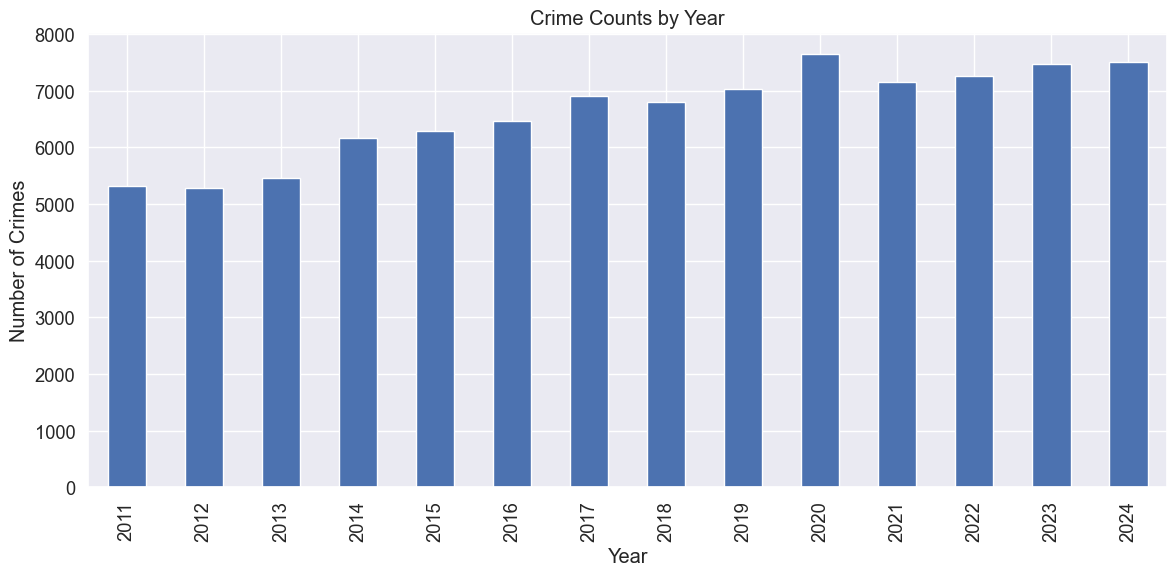

In [17]:
# Optional visualizations
if 'Year' in crime_data.columns:
    # Crime counts by year
    plt.figure(figsize=(12, 6))
    crime_data.groupby('Year').size().plot(kind='bar')
    plt.title('Crime Counts by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.tight_layout()
    plt.show()

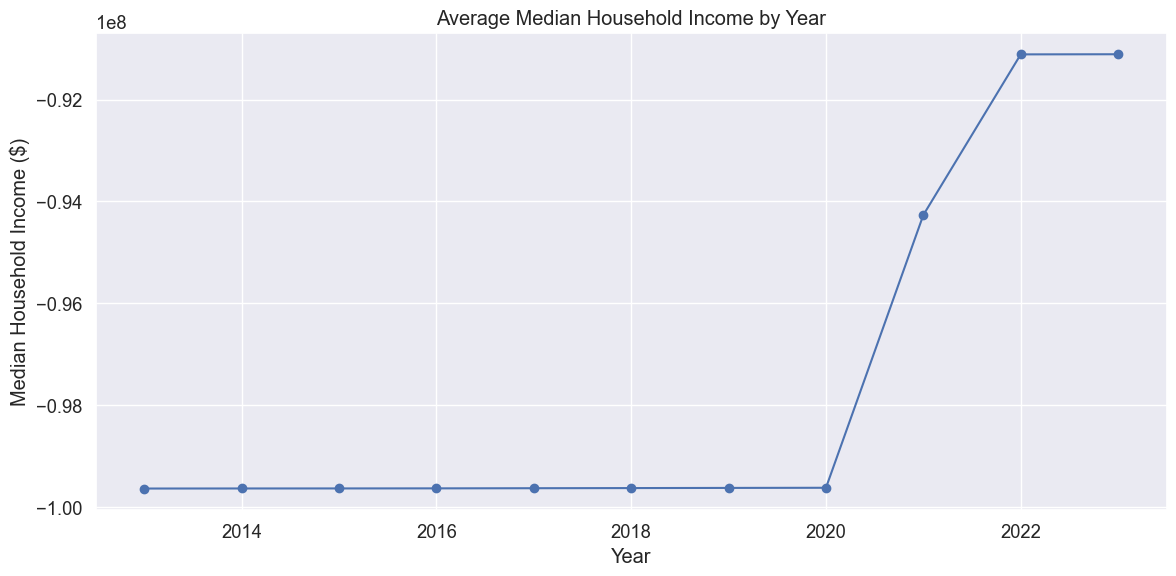

In [18]:
# ACS data visualization
plt.figure(figsize=(12, 6))
acs_data.groupby('year')['household_median_income_1yr'].mean().plot(kind='line', marker='o')
plt.title('Average Median Household Income by Year')
plt.xlabel('Year')
plt.ylabel('Median Household Income ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

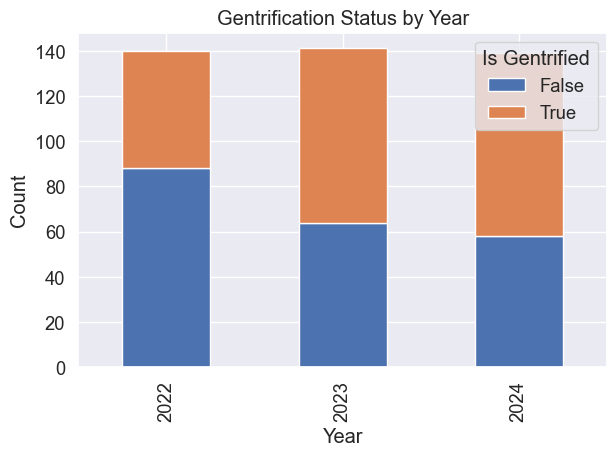

In [19]:
# Business data - Gentrification by year
plt.figure(figsize=(10, 6))
gentrification_by_year = business_data.groupby(['yr', 'is_gentrified']).size().unstack()
gentrification_by_year.plot(kind='bar', stacked=True)
plt.title('Gentrification Status by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Is Gentrified')
plt.tight_layout()
plt.show()

In [20]:
acs_data

,zcta,year,merge_key,number_of_households,household_median_income_1yr,household_mean_income_1yr,number_of_rent_home,median_rent,number_of_owned_home,median_home_value,population_25_and_over,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,total_population,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,housing_units,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
0,10001,2023,2023_10001,15097,123393,205444,11399,3024,3570,793000,22724,2.112304,5.034325,8.638444,9.514170,3.199261,41.471572,30.029924,29079,10.653736,20.898243,41.916847,20.898243,15097,55.010929,29.297211,9.518447,6.173412
1,10002,2023,2023_10002,35771,46525,93314,28916,1207,6660,808500,59418,13.788751,15.215928,17.723585,10.347033,3.970177,26.542462,12.412064,75517,11.974787,15.850736,33.393805,32.453620,35771,44.222974,33.211261,12.521316,10.044449
2,10003,2023,2023_10003,25080,153750,248577,16196,2772,8701,1137000,36544,2.982706,1.313485,4.802430,6.170644,2.531195,44.729641,37.469899,53825,17.103576,25.629354,30.918718,21.935903,25080,53.337321,32.149123,10.071770,4.441786
3,10004,2023,2023_10004,1775,220592,309645,1145,3501,630,1866400,3010,0.531561,0.365449,1.661130,6.378738,0.166113,42.624585,48.272425,3875,11.561290,16.077419,48.103226,14.090323,1775,40.338028,30.366197,15.718310,13.577465
4,10005,2023,2023_10005,5156,211810,279387,4276,3501,880,1387200,7325,0.887372,1.665529,5.870307,6.484642,0.832765,50.552901,33.706485,9238,5.877896,35.570470,45.605109,9.092877,5156,53.316524,31.400310,7.059736,8.223429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343,11691,2013,2013_11691,18942,39409,56640,13955,1012,4825,448200,35984,12.500000,14.400000,28.300000,16.900000,6.400000,13.500000,8.000000,61091,21.800000,15.600000,29.600000,20.500000,18942,29.100000,22.400000,15.200000,33.200000
2344,11692,2013,2013_11692,5974,43354,60455,3918,875,2000,355800,11102,10.700000,13.600000,28.700000,19.900000,7.800000,13.000000,6.200000,17674,22.000000,13.800000,34.700000,20.700000,5974,26.400000,23.100000,23.100000,27.300000
2345,11693,2013,2013_11693,4518,50570,60995,2419,831,1992,323100,7664,3.400000,15.500000,30.200000,19.500000,7.400000,17.200000,6.600000,11335,19.700000,12.100000,38.500000,23.100000,4518,31.600000,30.100000,18.300000,19.900000
2346,11694,2013,2013_11694,8190,76944,93633,3494,1161,4570,623200,15705,5.100000,6.900000,22.700000,19.200000,8.400000,19.800000,17.700000,21725,19.100000,9.000000,35.100000,29.100000,8190,32.500000,28.000000,17.700000,21.800000
